Mental Health Analysis

In [9]:
# ============================================================
# PHASE 1 — DATA LOADING + DATA CLEANING
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. LOAD THE DATASET
# ------------------------------------------------------------

# Read the CSV file and store it as a Pandas DataFrame
df = pd.read_csv("mental_health.csv")

# ------------------------------------------------------------
# 2. BASIC INSPECTION
# ------------------------------------------------------------

# Display the first 5 rows
# Helps us get a quick idea of what the dataset looks like
print("First 5 rows:")
display(df.head())


# Check the number of rows and columns
# shape[0] → number of rows
# shape[1] → number of columns
print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# Display all column names
# Helps us understand what features are available
print("\nColumn Names:")
print(df.columns.tolist())


# Display the data type of every column
# object/string → usually categorical/text
# int/float → numerical
print("\nData Types:")
print(df.dtypes)


# Give a general summary of the DataFrame
# Shows columns, non-null values, data types and memory usage
print("\nDataset Information:")
df.info()


# ------------------------------------------------------------
# 3. CHECK MISSING VALUES
# ------------------------------------------------------------

# isnull() identifies missing values
# sum() counts the missing values in each column
missing_values = df.isnull().sum()

print("\nMissing Values in Each Column:")
print(missing_values)


# Calculate the percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


# Show only columns that actually contain missing values
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
]

print("\nColumns With Missing Values:")
display(missing_summary)


# ------------------------------------------------------------
# 4. CHECK DUPLICATE ROWS
# ------------------------------------------------------------

# duplicated() identifies rows that are completely identical
# sum() counts how many duplicate rows exist
duplicate_count = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicate_count)


# Remove duplicate rows
# Only appropriate when identical rows represent accidental duplicates
df = df.drop_duplicates()


# ------------------------------------------------------------
# 5. IDENTIFY CATEGORICAL COLUMNS
# ------------------------------------------------------------

# Find columns containing text/category values
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)


# ------------------------------------------------------------
# 6. CLEAN TEXT IN CATEGORICAL COLUMNS
# ------------------------------------------------------------

# Remove unnecessary spaces from the beginning/end
# Convert text to lowercase so categories are consistent
#
# Example:
# " Male " → "male"
# " INDIA" → "india"
#
# This prevents values that mean the same thing from
# being treated as different categories.

for column in categorical_columns:

    df[column] = (
        df[column]
        .str.strip()
        .str.lower()
    )


# ------------------------------------------------------------
# 7. CHECK UNIQUE VALUES IN CATEGORICAL COLUMNS
# ------------------------------------------------------------

# unique() tells us what categories exist
# This helps detect spelling mistakes or unexpected values

print("\nUnique Values in Categorical Columns:")

for column in categorical_columns:

    print("\n" + "=" * 50)
    print(column)

    print(df[column].unique())


# ------------------------------------------------------------
# 8. CHECK CATEGORY FREQUENCIES
# ------------------------------------------------------------

# value_counts() tells us how frequently each category occurs
# This helps detect rare/unexpected categories

print("\nCategory Frequencies:")

for column in categorical_columns:

    print("\n" + "=" * 50)
    print(column)

    print(df[column].value_counts())


# ------------------------------------------------------------
# 9. IDENTIFY NUMERICAL COLUMNS
# ------------------------------------------------------------

# Find columns containing numerical values
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)


# ------------------------------------------------------------
# 10. STATISTICAL SUMMARY OF NUMERICAL VARIABLES
# ------------------------------------------------------------

# describe() gives:
# count
# mean
# standard deviation
# minimum
# 25th percentile
# median
# 75th percentile
# maximum

print("\nNumerical Summary:")
display(df[numerical_columns].describe())


# ------------------------------------------------------------
# 11. CHECK FOR SUSPICIOUS VALUES
# ------------------------------------------------------------

# Example: check the range of important numerical variables
# We don't automatically remove unusual values.
# First we investigate whether they are actually incorrect.

print("\nAge Range:")
print("Minimum:", df["Age"].min())
print("Maximum:", df["Age"].max())


print("\nWork Hours Range:")
print("Minimum:", df["Work_Hours_Per_Week"].min())
print("Maximum:", df["Work_Hours_Per_Week"].max())


print("\nSleep Hours Range:")
print("Minimum:", df["Sleep_Hours_Night"].min())
print("Maximum:", df["Sleep_Hours_Night"].max())


# ------------------------------------------------------------
# 12. CHECK THE TARGET VARIABLE
# ------------------------------------------------------------

# This is the variable we eventually want to predict/analyze
target = "Has_Mental_Health_Issue"

print("\nTarget Variable:")
print(target)


# Count how many observations belong to each target class
print("\nTarget Counts:")
print(df[target].value_counts())


# Calculate the percentage of each target class
print("\nTarget Percentages:")
print(df[target].value_counts(normalize=True) * 100)


First 5 rows:


,Age,Gender,Country,Education,Marital_Status,Income_Level,Employment_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,...,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Discuss_Mental_Health,Has_Mental_Health_Issue
0,40,Male,USA,Some College,Single,Middle,Full-time,27,No,6,...,1,0,0,0,9,3,4,6,Sometimes,1
1,33,Male,India,Bachelor,Married,Middle,Unemployed,47,No,6,...,0,0,0,0,3,2,7,7,Sometimes,1
2,42,Male,Other,High School,Single,Low,Full-time,53,No,1,...,1,0,0,1,5,3,6,9,Sometimes,1
3,53,Male,Germany,Bachelor,Single,Middle,Unemployed,42,No,10,...,0,1,0,0,1,3,10,5,Never,1
4,32,Female,India,Bachelor,Single,High,Student,13,No,4,...,0,0,0,0,1,5,1,6,Sometimes,1



Dataset Shape:
Rows: 10000
Columns: 51

Column Names:
['Age', 'Gender', 'Country', 'Education', 'Marital_Status', 'Income_Level', 'Employment_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Stress_Level', 'Work_Life_Balance', 'Ever_Bullied_At_Work', 'Company_Mental_Health_Support', 'Exercise_Per_Week', 'Sleep_Hours_Night', 'Caffeine_Drinks_Day', 'Alcohol_Frequency', 'Smoking', 'Screen_Time_Hours_Day', 'Social_Media_Hours_Day', 'Hobby_Time_Hours_Week', 'Diet_Quality', 'Financial_Stress', 'Feeling_Sad_Down', 'Loss_Of_Interest', 'Sleep_Trouble', 'Fatigue', 'Poor_Appetite_Or_Overeating', 'Feeling_Worthless', 'Concentration_Difficulty', 'Anxious_Nervous', 'Panic_Attacks', 'Mood_Swings', 'Irritability', 'Obsessive_Thoughts', 'Compulsive_Behavior', 'Self_Harm_Thoughts', 'Suicidal_Thoughts', 'Family_History_Mental_Illness', 'Previously_Diagnosed', 'Ever_Sought_Treatment', 'On_Therapy_Now', 'On_Medication', 'Trauma_History', 'Social_Support', 'Close_Friends_Count', 'Fe

,Missing_Count,Missing_Percentage



Number of Duplicate Rows: 0

Categorical Columns:
['Gender', 'Country', 'Education', 'Marital_Status', 'Income_Level', 'Employment_Status', 'Remote_Work', 'Company_Mental_Health_Support', 'Exercise_Per_Week', 'Alcohol_Frequency', 'Smoking', 'Diet_Quality', 'Discuss_Mental_Health']

Unique Values in Categorical Columns:

Gender
['male' 'female' 'non-binary' 'prefer not to say']

Country
['usa' 'india' 'other' 'germany' 'uk' 'brazil']

Education
['some college' 'bachelor' 'high school' 'master' 'phd']

Marital_Status
['single' 'married' 'divorced' 'widowed']

Income_Level
['middle' 'low' 'high']

Employment_Status
['full-time' 'unemployed' 'student' 'part-time' 'self-employed']

Remote_Work
['no' 'hybrid' 'yes']

Company_Mental_Health_Support
['no' 'not sure' 'yes']

Exercise_Per_Week
['1-2 times' '3-4 times' 'never' '5+ times']

Alcohol_Frequency
['never' 'weekly' 'rarely' 'daily']

Smoking
['former' 'current' 'never']

Diet_Quality
['average' 'good' 'excellent' 'poor']

Discuss_Mental

,Age,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Sleep_Hours_Night,Caffeine_Drinks_Day,Screen_Time_Hours_Day,Social_Media_Hours_Day,...,Previously_Diagnosed,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Has_Mental_Health_Issue
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,34.94790,39.657900,5.502700,5.49390,5.489400,0.247400,6.815450,2.023300,7.064590,3.141810,...,0.248000,0.36220,0.191000,0.184300,0.25060,5.459700,4.019300,5.469700,5.449700,0.921600
std,11.15639,10.016711,2.884341,2.88163,2.875572,0.431523,1.377975,1.427432,2.955874,2.254204,...,0.431873,0.48066,0.393109,0.387748,0.43338,2.882986,1.998431,2.872021,2.862322,0.268813
min,18.00000,0.000000,1.000000,1.00000,1.000000,0.000000,3.000000,0.000000,1.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,1.000000,0.000000,1.000000,1.000000,0.000000
25%,26.00000,33.000000,3.000000,3.00000,3.000000,0.000000,5.900000,1.000000,5.000000,1.300000,...,0.000000,0.00000,0.000000,0.000000,0.00000,3.000000,3.000000,3.000000,3.000000,1.000000
50%,34.00000,40.000000,6.000000,6.00000,5.000000,0.000000,6.800000,2.000000,7.000000,3.000000,...,0.000000,0.00000,0.000000,0.000000,0.00000,5.000000,4.000000,5.000000,5.000000,1.000000
75%,43.00000,46.000000,8.000000,8.00000,8.000000,0.000000,7.700000,3.000000,9.100000,4.700000,...,0.000000,1.00000,0.000000,0.000000,1.00000,8.000000,5.000000,8.000000,8.000000,1.000000
max,75.00000,74.000000,10.000000,10.00000,10.000000,1.000000,11.000000,8.000000,16.000000,12.000000,...,1.000000,1.00000,1.000000,1.000000,1.00000,10.000000,13.000000,10.000000,10.000000,1.000000



Age Range:
Minimum: 18
Maximum: 75

Work Hours Range:
Minimum: 0
Maximum: 74

Sleep Hours Range:
Minimum: 3.0
Maximum: 11.0

Target Variable:
Has_Mental_Health_Issue

Target Counts:
Has_Mental_Health_Issue
1    9216
0     784
Name: count, dtype: int64

Target Percentages:
Has_Mental_Health_Issue
1    92.16
0     7.84
Name: proportion, dtype: float64


In [10]:
# ------------------------------------------------------------
# 13. FINAL DATA-CLEANING CHECK
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DATA CLEANING CHECK")
print("=" * 60)

# Final dataset size
print("\nDataset Shape:")
print(df.shape)


# Final duplicate check
print("\nDuplicate Rows:")
print(df.duplicated().sum())


# Final missing-value check
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


# Final data types
print("\nData Types:")
print(df.dtypes)


# Display cleaned dataset
print("\nCleaned Dataset:")
display(df.head())


FINAL DATA CLEANING CHECK

Dataset Shape:
(10000, 51)

Duplicate Rows:
0

Total Missing Values:
0

Data Types:
Age                                int64
Gender                            object
Country                           object
Education                         object
Marital_Status                    object
Income_Level                      object
Employment_Status                 object
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                   int64
Work_Stress_Level                  int64
Work_Life_Balance                  int64
Ever_Bullied_At_Work               int64
Company_Mental_Health_Support     object
Exercise_Per_Week                 object
Sleep_Hours_Night                float64
Caffeine_Drinks_Day                int64
Alcohol_Frequency                 object
Smoking                           object
Screen_Time_Hours_Day            float64
Social_Media_Hours_Day           float64
Hobby_Time_Hours_Week      

,Age,Gender,Country,Education,Marital_Status,Income_Level,Employment_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,...,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Discuss_Mental_Health,Has_Mental_Health_Issue
0,40,male,usa,some college,single,middle,full-time,27,no,6,...,1,0,0,0,9,3,4,6,sometimes,1
1,33,male,india,bachelor,married,middle,unemployed,47,no,6,...,0,0,0,0,3,2,7,7,sometimes,1
2,42,male,other,high school,single,low,full-time,53,no,1,...,1,0,0,1,5,3,6,9,sometimes,1
3,53,male,germany,bachelor,single,middle,unemployed,42,no,10,...,0,1,0,0,1,3,10,5,never,1
4,32,female,india,bachelor,single,high,student,13,no,4,...,0,0,0,0,1,5,1,6,sometimes,1


In [11]:
# ============================================================
# PHASE 2 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. IDENTIFY THE TARGET VARIABLE
# ============================================================

# This is the variable we ultimately want to understand/predict.
target = "Has_Mental_Health_Issue"


# ============================================================
# 2. TARGET DISTRIBUTION
# ============================================================

# Question:
# "How many observations belong to each target class?"
#
# value_counts() counts the number of times each value appears.

print("Target Counts:")
print(df[target].value_counts())

Target Counts:
Has_Mental_Health_Issue
1    9216
0     784
Name: count, dtype: int64



Target Percentages:
Has_Mental_Health_Issue
1    92.16
0     7.84
Name: proportion, dtype: float64


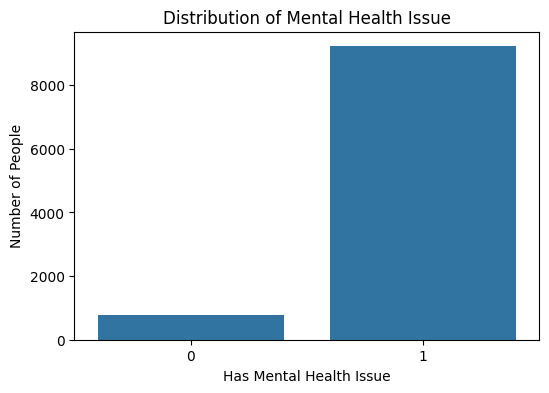

In [12]:
# Convert the counts into percentages.
# This tells us how much of the dataset belongs to each class.

print("\nTarget Percentages:")
print(df[target].value_counts(normalize=True) * 100)


# Visualize the target distribution.
# Since the target is categorical/binary, a count plot is appropriate.

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x=target
)

plt.title("Distribution of Mental Health Issue")
plt.xlabel("Has Mental Health Issue")
plt.ylabel("Number of People")

plt.show()

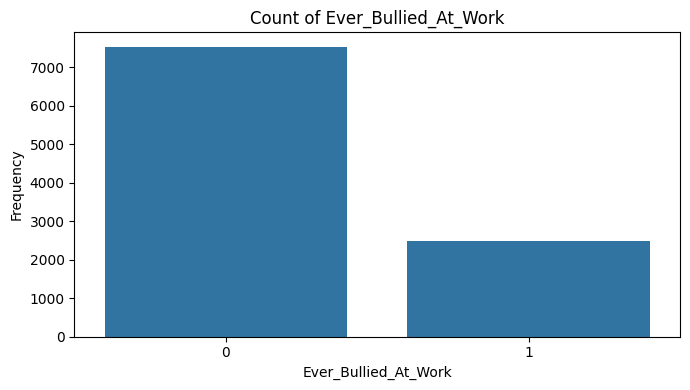

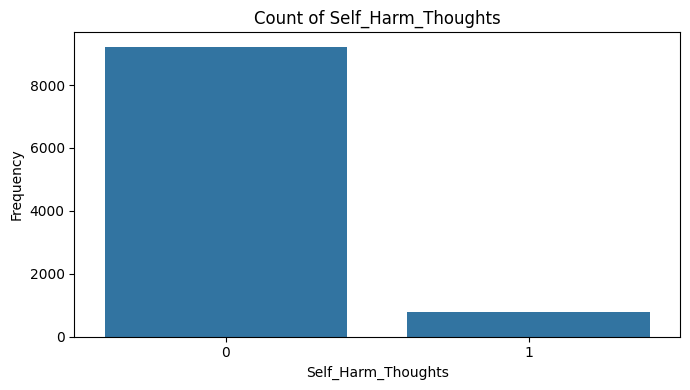

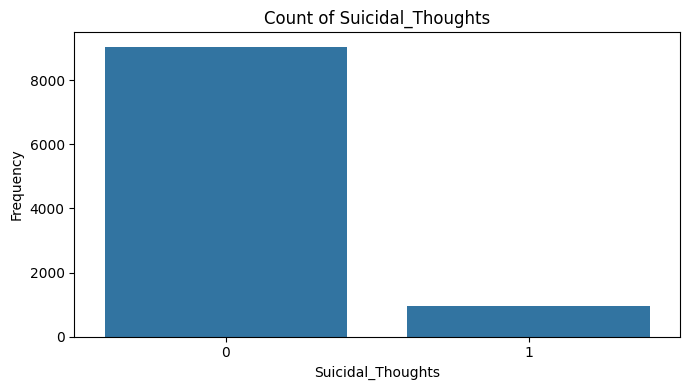

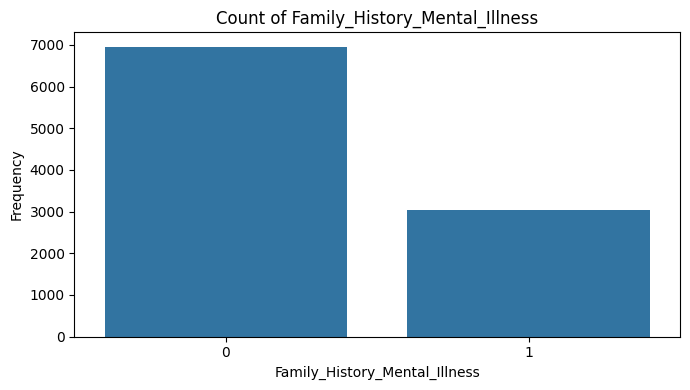

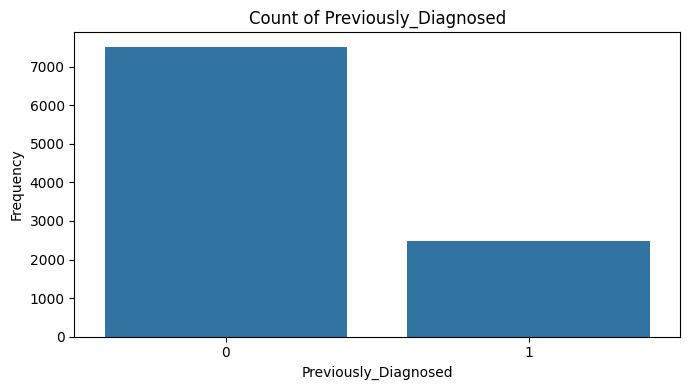

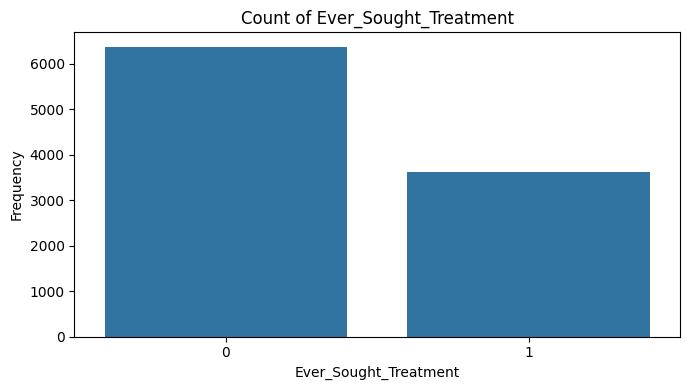

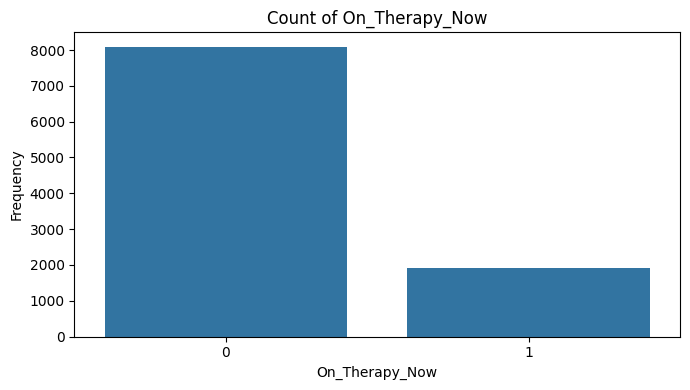

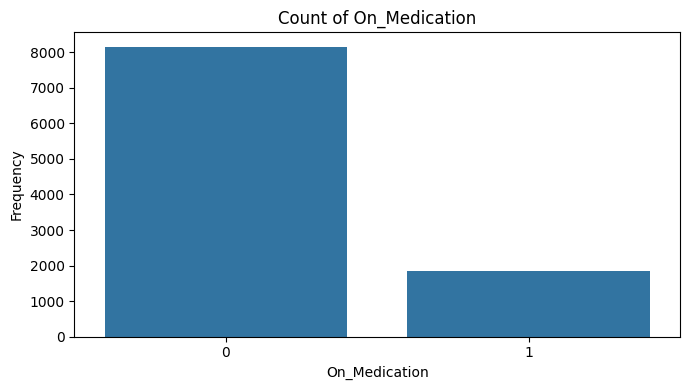

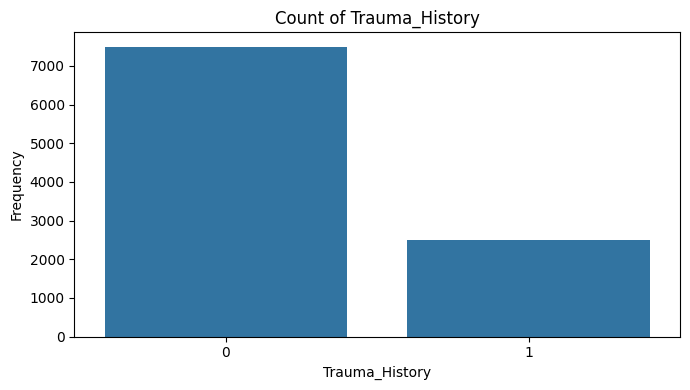

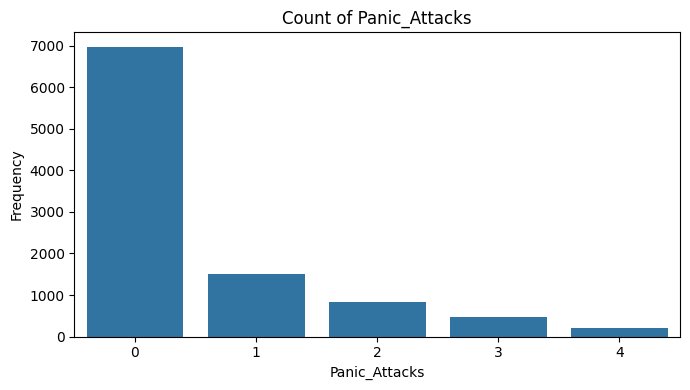

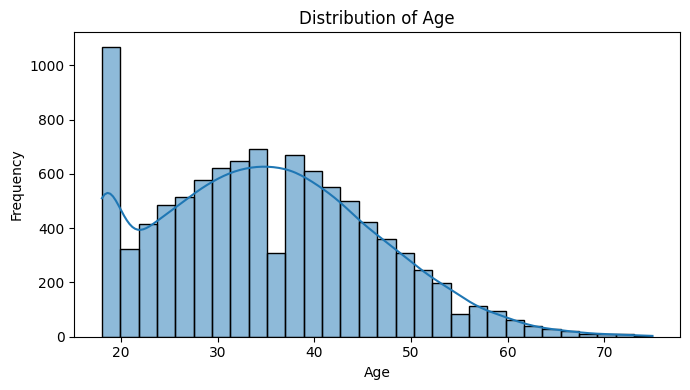

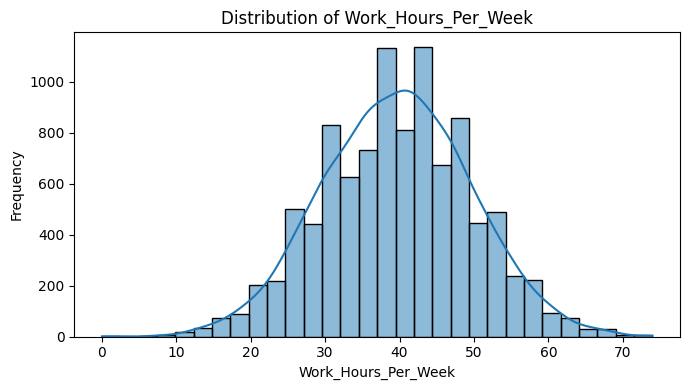

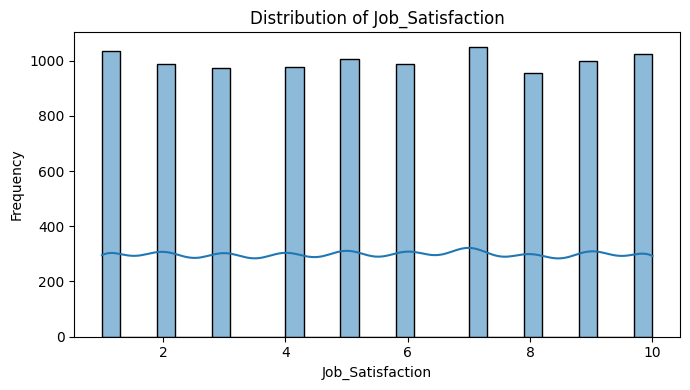

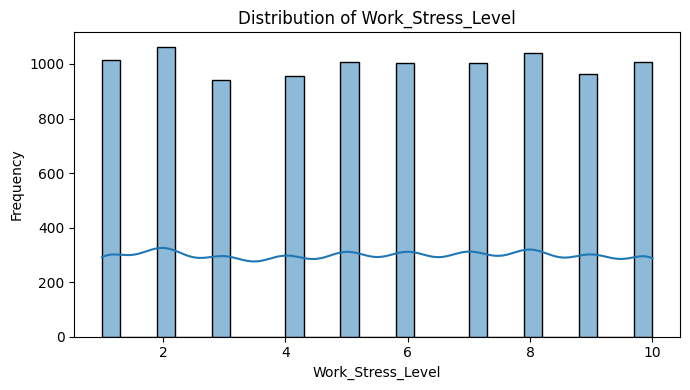

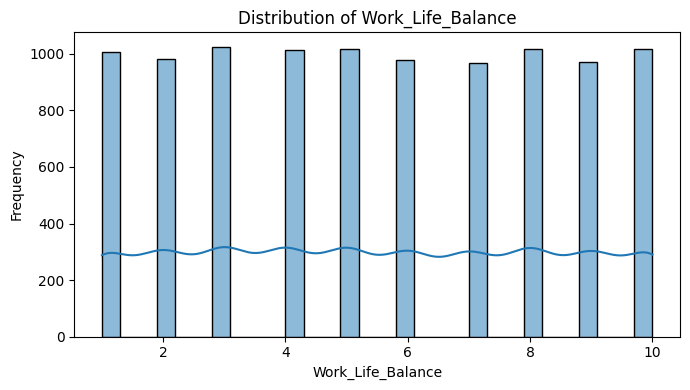

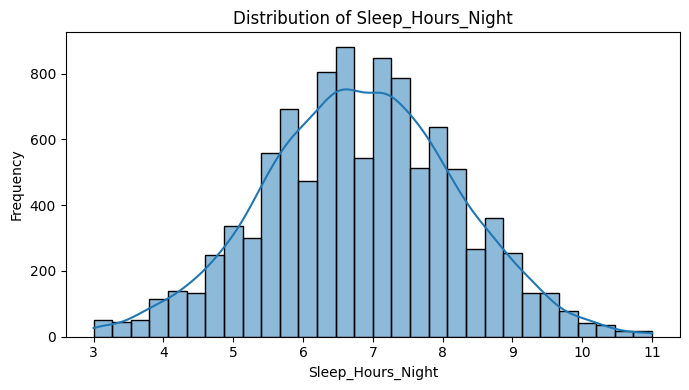

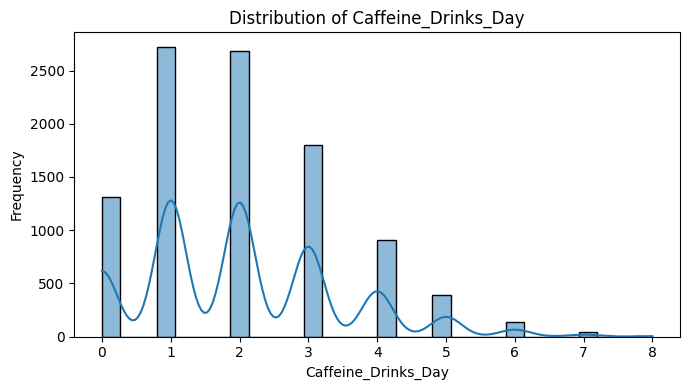

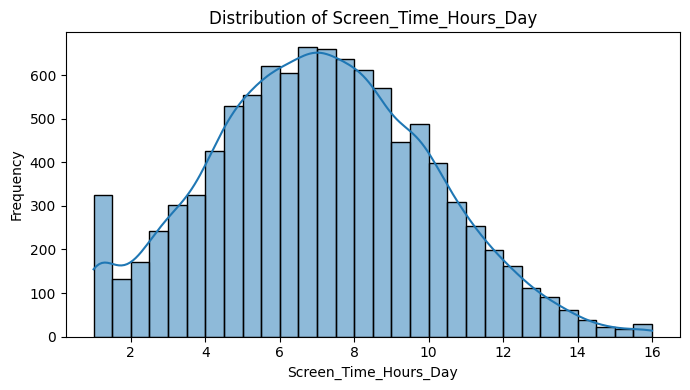

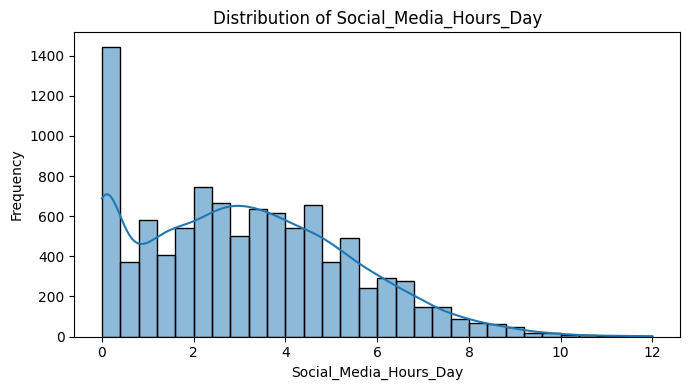

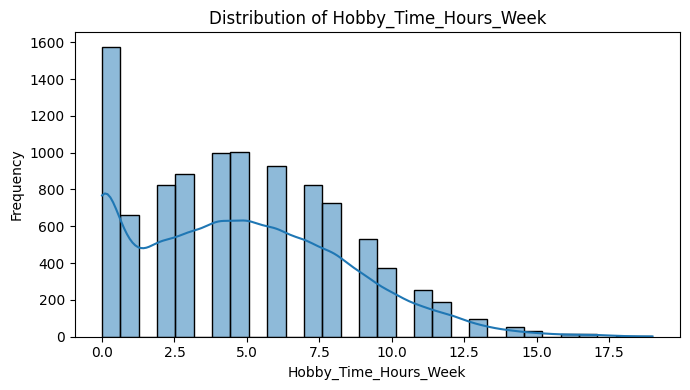

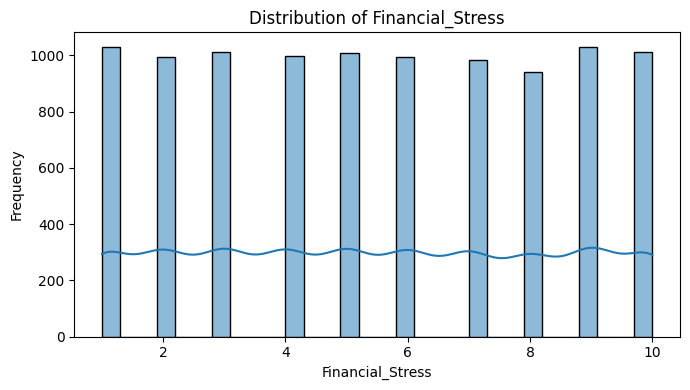

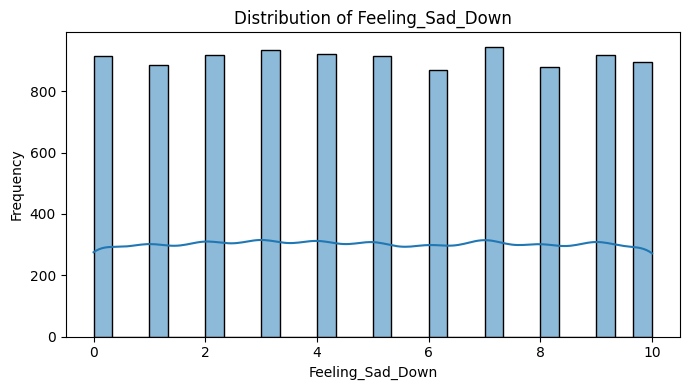

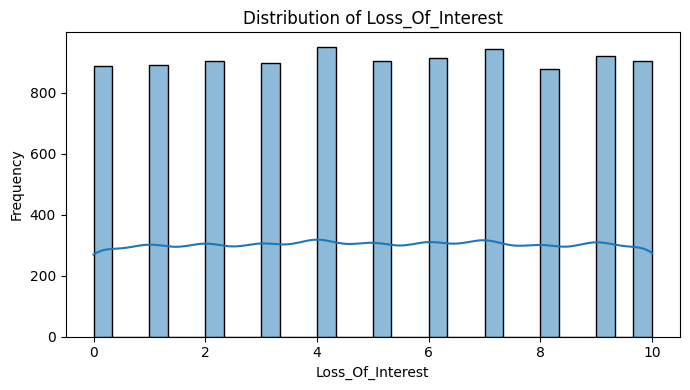

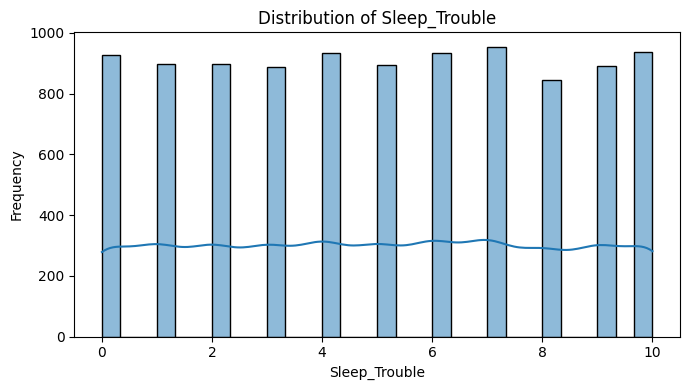

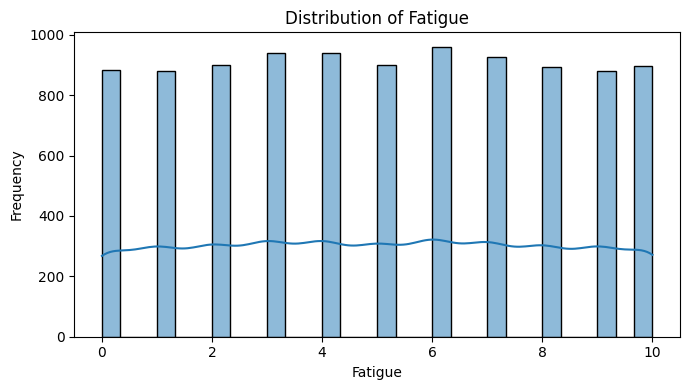

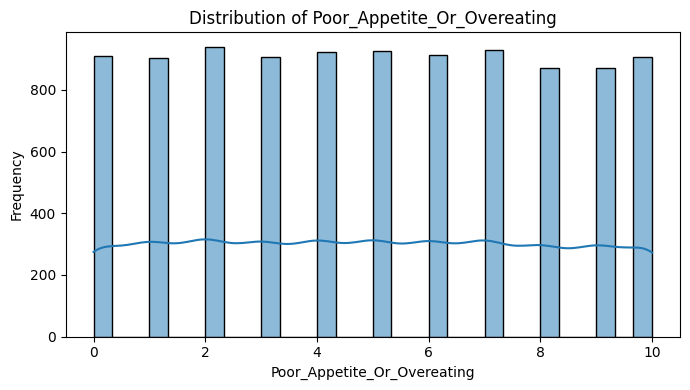

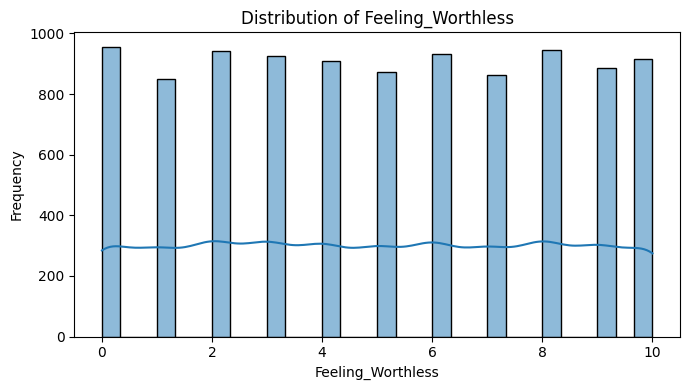

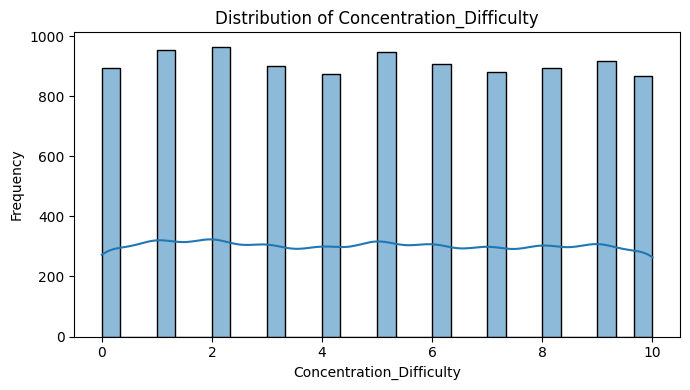

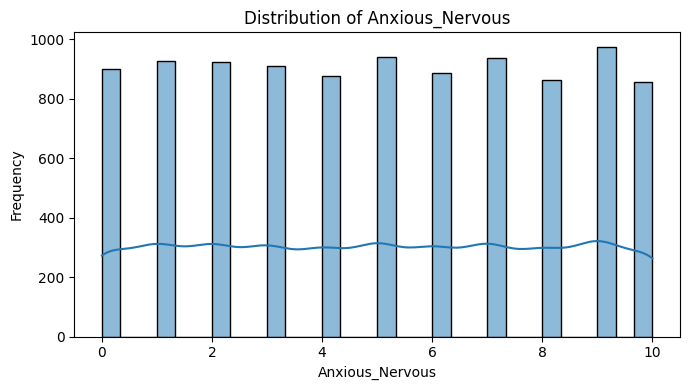

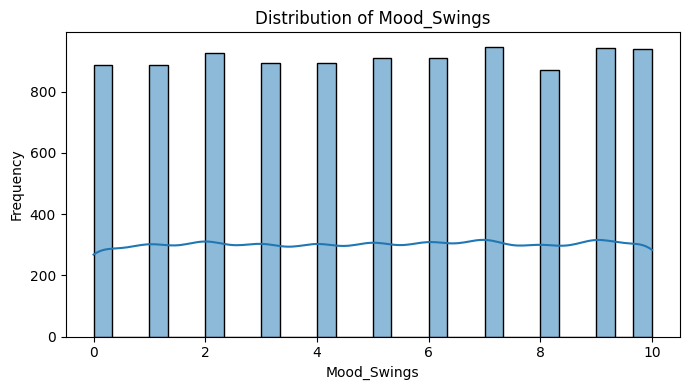

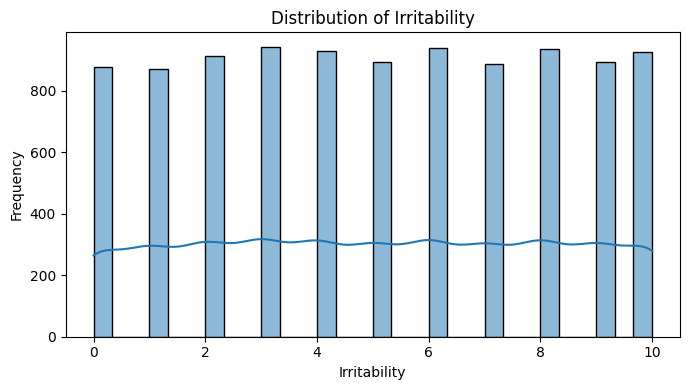

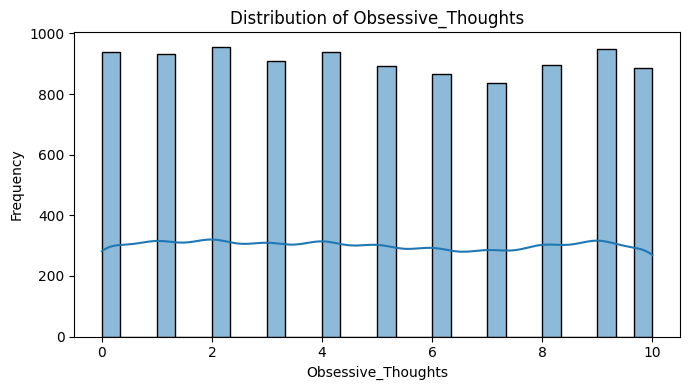

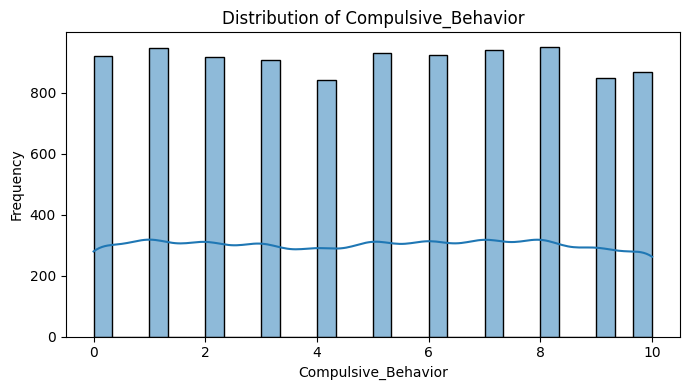

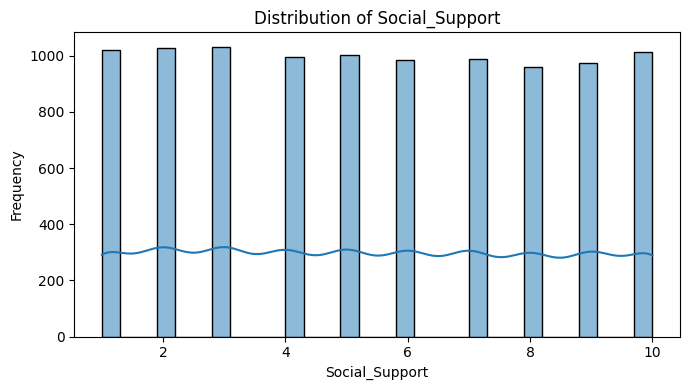

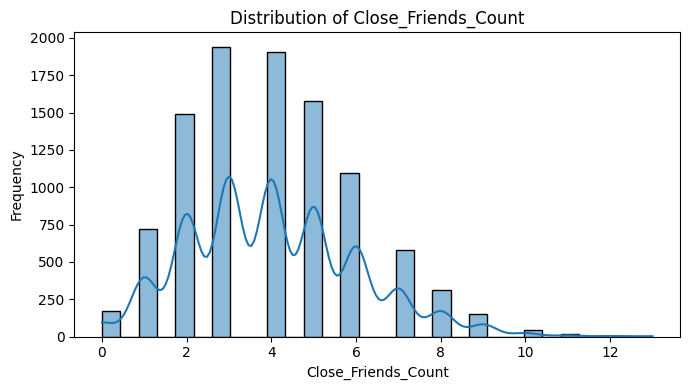

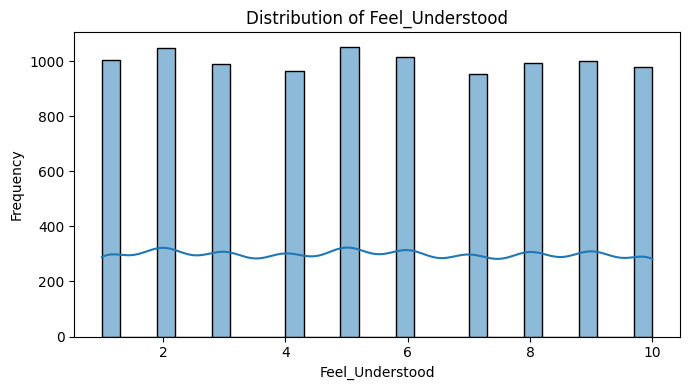

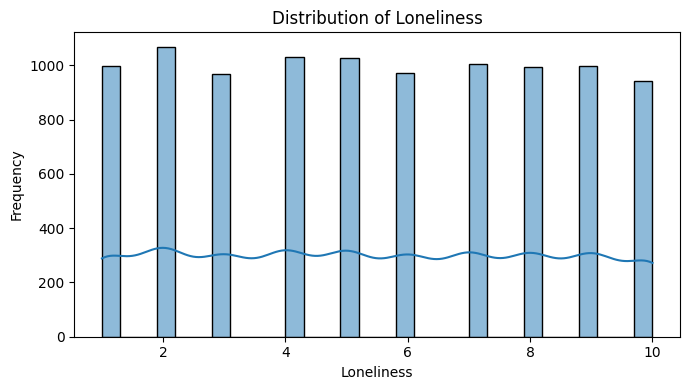

In [21]:
# ============================================================
# 5. DISTRIBUTION OF NUMERICAL VARIABLES
# ============================================================

# Separate binary numerical columns (0/1) from other numerical columns
binary_columns = [
    column for column in numerical_columns
    if set(df[column].dropna().unique()).issubset({0, 1})
]

# All other numerical columns
histogram_columns = [
    column for column in numerical_columns
    if column not in binary_columns
]


# ------------------------------------------------------------
# 5A. COUNT PLOTS FOR BINARY VARIABLES
# ------------------------------------------------------------

for column in binary_columns:

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"Count of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()
    
    
# Panic_Attacks is a discrete count variable
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Panic_Attacks"
)

plt.title("Count of Panic_Attacks")
plt.xlabel("Panic_Attacks")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5B. HISTOGRAMS FOR OTHER NUMERICAL VARIABLES
# ------------------------------------------------------------

for column in histogram_columns:
    
    if column == "Panic_Attacks":
        continue

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [42]:
''' since we couldnt find any strong 
    correlation between the target variable and other 
    features we will not consider this'''
    
target_corr = (
    corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

print(target_corr)

Work_Stress_Level                0.055028
Family_History_Mental_Illness    0.054693
Feeling_Sad_Down                 0.050075
Financial_Stress                 0.045807
Anxious_Nervous                  0.043630
Poor_Appetite_Or_Overeating      0.040525
Loneliness                       0.040237
Suicidal_Thoughts                0.038835
Trauma_History                   0.038176
Fatigue                          0.033911
Irritability                     0.033130
Compulsive_Behavior              0.031555
Obsessive_Thoughts               0.031200
Concentration_Difficulty         0.031196
Feeling_Worthless                0.030927
Self_Harm_Thoughts               0.029435
Mood_Swings                      0.027499
On_Medication                    0.022540
Sleep_Trouble                    0.021354
Work_Hours_Per_Week              0.020755
Loss_Of_Interest                 0.020239
Previously_Diagnosed             0.015017
Hobby_Time_Hours_Week            0.008953
Work_Life_Balance                0

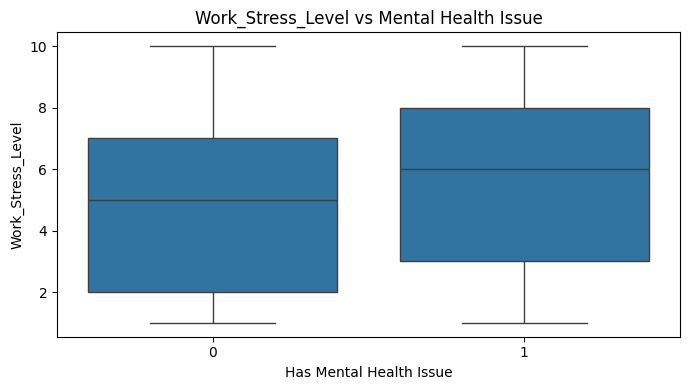

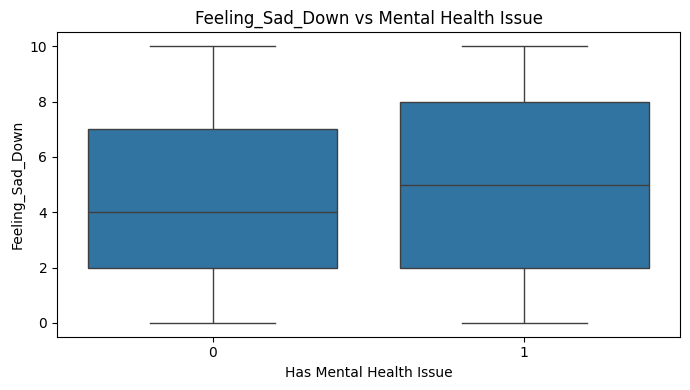

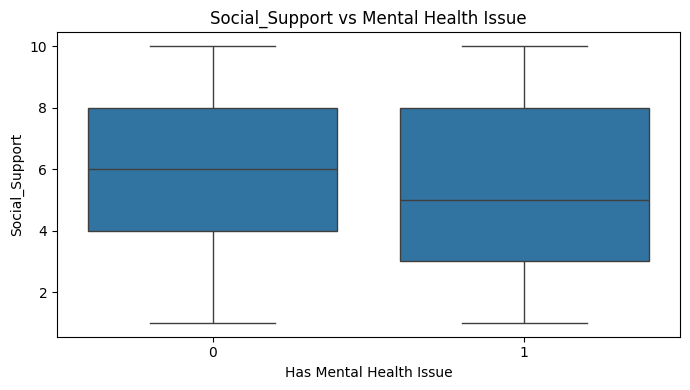

In [45]:
# Features we want to compare with the target
features = [
    "Work_Stress_Level",
    "Feeling_Sad_Down",
    "Social_Support",
]

# Create one boxplot for each feature
for feature in features:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Has_Mental_Health_Issue",
        y=feature
    )

    plt.title(f"{feature} vs Mental Health Issue")
    plt.xlabel("Has Mental Health Issue")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [46]:
pd.crosstab(
    df["Gender"],
    df["Has_Mental_Health_Issue"],
    normalize="index"
) * 100

Has_Mental_Health_Issue,0,1
Gender,,
female,8.462796,91.537204
male,7.142857,92.857143
non-binary,8.544304,91.455696
prefer not to say,7.758621,92.241379


In [47]:
pd.crosstab(
    df["Remote_Work"],
    df["Has_Mental_Health_Issue"],
    normalize="index"
) * 100

Has_Mental_Health_Issue,0,1
Remote_Work,,
hybrid,7.720021,92.279979
no,8.128278,91.871722
yes,7.454017,92.545983


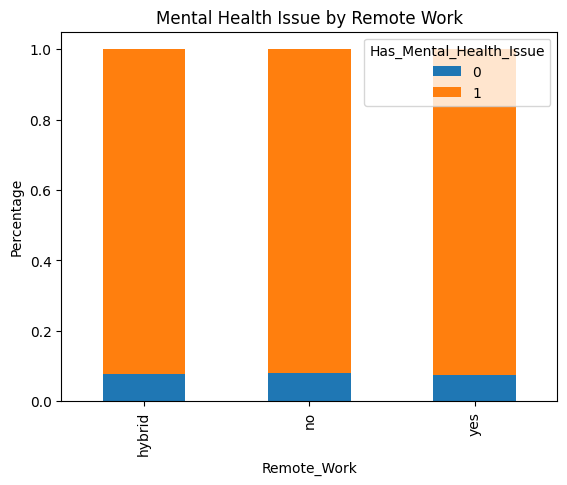

In [48]:
pd.crosstab(
    df["Remote_Work"],
    df["Has_Mental_Health_Issue"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True
)

plt.ylabel("Percentage")
plt.title("Mental Health Issue by Remote Work")
plt.show()

In [49]:
# List of categorical features we want to investigate
categorical_features = [
    "Gender",
    "Country",
    "Education",
    "Marital_Status",
    "Income_Level",
    "Employment_Status",
    "Remote_Work",
    "Company_Mental_Health_Support",
    "Exercise_Per_Week",
    "Alcohol_Frequency",
    "Smoking",
    "Diet_Quality",
    "Discuss_Mental_Health"
]

# Compare the percentage of target 0 and 1 within each category
for feature in categorical_features:

    print("\n" + "=" * 60)
    print(feature)

    result = pd.crosstab(
        df[feature],
        df["Has_Mental_Health_Issue"],
        normalize="index"
    ) * 100

    print(result.round(2))


Gender
Has_Mental_Health_Issue     0      1
Gender                              
female                   8.46  91.54
male                     7.14  92.86
non-binary               8.54  91.46
prefer not to say        7.76  92.24

Country
Has_Mental_Health_Issue     0      1
Country                             
brazil                   8.36  91.64
germany                  7.23  92.77
india                    7.28  92.72
other                    8.17  91.83
uk                       9.60  90.40
usa                      7.03  92.97

Education
Has_Mental_Health_Issue     0      1
Education                           
bachelor                 8.22  91.78
high school              8.04  91.96
master                   7.33  92.67
phd                      7.42  92.58
some college             7.55  92.45

Marital_Status
Has_Mental_Health_Issue     0      1
Marital_Status                      
divorced                 6.93  93.07
married                  8.14  91.86
single                   7.89  

In [52]:
# Target
target = "Has_Mental_Health_Issue"

# Columns we don't want to use for prediction
leakage_columns = [
    "Previously_Diagnosed",
    "On_Therapy_Now",
    "On_Medication"
]

# Create feature dataset
X = df.drop(columns=[target] + leakage_columns)

# Target
y = df[target]

print("Features:", X.shape)
print("Target:", y.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

Features: (10000, 47)
Target: (10000,)
X shape: (10000, 47)
y shape: (10000,)

Categorical columns:
['Gender', 'Country', 'Education', 'Marital_Status', 'Income_Level', 'Employment_Status', 'Remote_Work', 'Company_Mental_Health_Support', 'Exercise_Per_Week', 'Alcohol_Frequency', 'Smoking', 'Diet_Quality', 'Discuss_Mental_Health']


In [58]:
# Load the ORIGINAL dataset again
df = pd.read_csv("mental_health.csv")

# Clean categorical text
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

for column in categorical_columns:
    df[column] = df[column].str.strip().str.lower()

# These categories have a meaningful order

exercise_mapping = {
    "never": 0,
    "1-2 times": 1,
    "3-4 times": 2,
    "5+ times": 3
}

income_mapping = {
    "low": 0,
    "middle": 1,
    "high": 2
}

alcohol_mapping = {
    "never": 0,
    "rarely": 1,
    "weekly": 2,
    "daily": 3
}

diet_mapping = {
    "poor": 0,
    "average": 1,
    "good": 2,
    "excellent": 3
}

discuss_mapping = {
    "never": 0,
    "rarely": 1,
    "sometimes": 2,
    "yes easily": 3
}

df["Exercise_Per_Week"] = df["Exercise_Per_Week"].map(exercise_mapping)
df["Income_Level"] = df["Income_Level"].map(income_mapping)
df["Alcohol_Frequency"] = df["Alcohol_Frequency"].map(alcohol_mapping)
df["Diet_Quality"] = df["Diet_Quality"].map(diet_mapping)
df["Discuss_Mental_Health"] = df["Discuss_Mental_Health"].map(discuss_mapping)

In [59]:
# These categories have NO meaningful order,
# so use one-hot encoding.

nominal_columns = [
    "Gender",
    "Country",
    "Education",
    "Marital_Status",
    "Employment_Status",
    "Remote_Work",
    "Company_Mental_Health_Support",
    "Smoking"
]

df = pd.get_dummies(
    df,
    columns=nominal_columns,
    drop_first=True,
    dtype=int
)

print(df.shape)
print(df.dtypes)
display(df.head())

(10000, 68)
Age                                       int64
Income_Level                              int64
Work_Hours_Per_Week                       int64
Job_Satisfaction                          int64
Work_Stress_Level                         int64
                                          ...  
Remote_Work_yes                           int64
Company_Mental_Health_Support_not sure    int64
Company_Mental_Health_Support_yes         int64
Smoking_former                            int64
Smoking_never                             int64
Length: 68, dtype: object


,Age,Income_Level,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Exercise_Per_Week,Sleep_Hours_Night,Caffeine_Drinks_Day,...,Employment_Status_part-time,Employment_Status_self-employed,Employment_Status_student,Employment_Status_unemployed,Remote_Work_no,Remote_Work_yes,Company_Mental_Health_Support_not sure,Company_Mental_Health_Support_yes,Smoking_former,Smoking_never
0,40,1,27,6,7,7,0,1,6.2,3,...,0,0,0,0,1,0,0,0,1,0
1,33,1,47,6,1,5,0,1,9.6,3,...,0,0,0,1,1,0,1,0,0,0
2,42,0,53,1,3,8,0,2,7.7,1,...,0,0,0,0,1,0,1,0,1,0
3,53,1,42,10,3,5,0,0,6.4,1,...,0,0,0,1,1,0,0,0,1,0
4,32,2,13,4,7,7,1,1,7.7,0,...,0,0,1,0,1,0,1,0,0,0
